In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('data/used_cars.csv')

In [ ]:
# data cleaning
df = df[['model_year', 'milage', 'fuel_type',"accident", "price"]].dropna()
df_new = df[~df['fuel_type'].isin(["not supported", "–"])].copy(deep=True)
df_new['price'] = np.log(df_new['price'].str.replace(r'[$,]', '', regex=True).astype(float))
df_new['milage'] = (
    df_new['milage']
    .str.replace(r'[^\d]', '', regex=True)  # keep only digits
    .astype(float)
)

df_new['fuel_type'] = df_new['fuel_type'].astype('category')
df_new['accident'] = df_new['accident'].map({
    'None reported': 0,
    'At least 1 accident or damage reported': 1
})
current_year = 2026
df_new['age'] = current_year - df_new['model_year'].astype(int)
print(df_new.head())

   model_year   milage      fuel_type  accident      price  age
0        2013  51000.0  E85 Flex Fuel         1   9.239899   13
1        2021  34742.0       Gasoline         1  10.545473    5
2        2022  22372.0       Gasoline         0  10.907753    4
3        2015  88900.0         Hybrid         0   9.648595   11
4        2021   9835.0       Gasoline         0  10.463075    5


['E85 Flex Fuel', 'Gasoline', 'Hybrid', 'Diesel', 'Plug-In Hybrid']
Categories (5, object): ['Diesel', 'E85 Flex Fuel', 'Gasoline', 'Hybrid', 'Plug-In Hybrid']


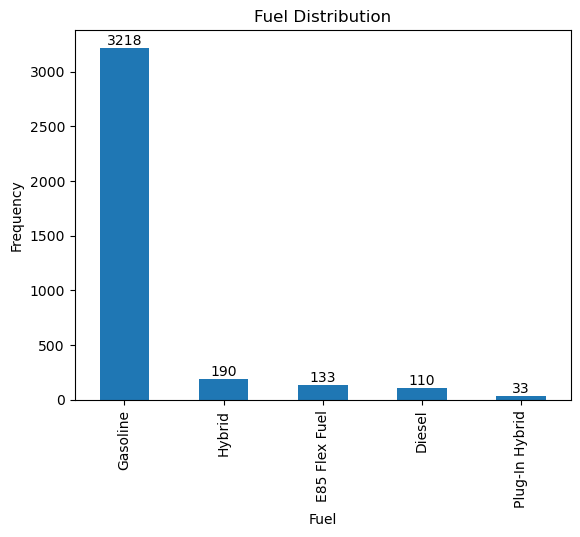

In [ ]:
print(df_new['fuel_type'].unique())
counts = df_new["fuel_type"].value_counts()

ax = counts.plot(kind='bar')
for i, v in enumerate(counts):
    ax.text(i, v, str(v), ha='center', va='bottom')

plt.title('Fuel Distribution')
plt.xlabel('Fuel')
plt.ylabel('Frequency')
plt.show()

As we can see the number of cars in different groups are quite imbalanced. To make it slightly better we merge cars with Hybrid power, plug-in hybrid power and Flex fuel power as one catagory, and make Diesel the same category with gasoline.

In [11]:
# Save the "Traditional fuel type" dataset and "Green Fuel type" dataset
df_traditional = df_new[(df_new["fuel_type"]=="Gasoline") | (df_new["fuel_type"]=="Diesel")]
df_green = df_new[(df_new["fuel_type"]!="Gasoline") & (df_new["fuel_type"]!="Diesel")]

# Convert the cleaned dataset to csv for R to process
df_traditional.to_csv('data/traditional.csv', index=False)
df_green.to_csv('data/green.csv', index=False)

The following is some visualizations: 

Text(0.5, 1.0, 'Accident vs Price')

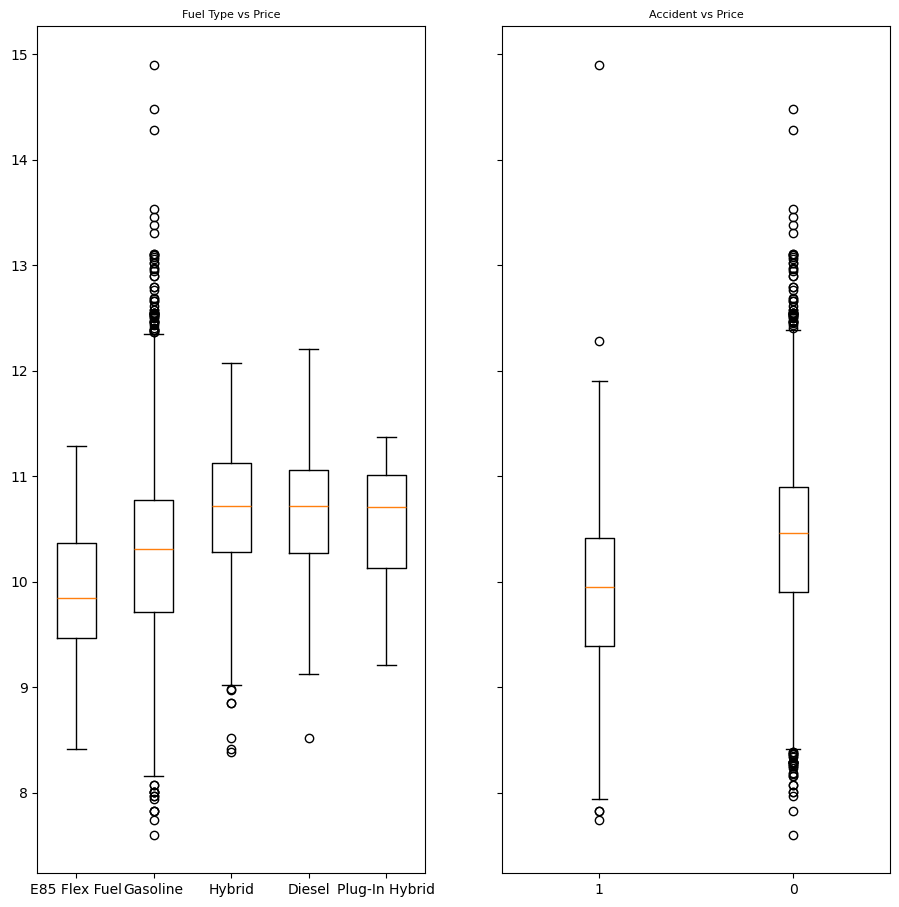

In [16]:
# Visualization part 1
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(11, 11), sharey=True)
# Boxplot of fuel type vs price:
fuel_types = df_new["fuel_type"].unique()
price_groups = [df_new[df_new["fuel_type"] == ft]["price"] for ft in fuel_types]

axs[0].boxplot(price_groups, tick_labels=fuel_types)
axs[0].set_title('Fuel Type vs Price', fontsize=8)
# Boxplot of accident vs price:
accident_types = df_new["accident"].unique()
price_groups_acc = [df_new[df_new["accident"] == ac]["price"] for ac in accident_types]

axs[1].boxplot(price_groups_acc, tick_labels=accident_types)
axs[1].set_title('Accident vs Price', fontsize=8)

Text(0.5, 1.0, 'Mileage vs. Car Price')

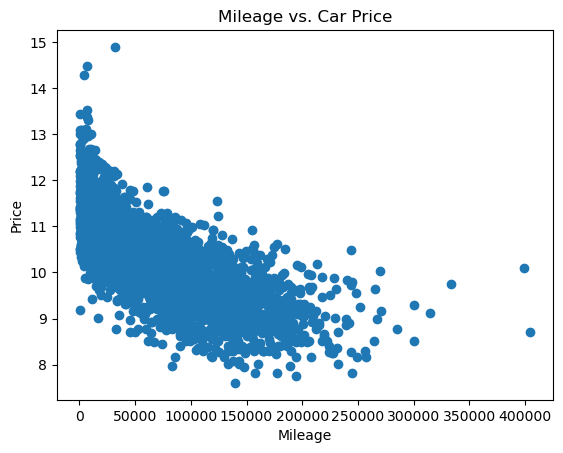

In [17]:
# Visualization part 2:
# Scatter plot of Mileage vs price:
plt.scatter(df_new["milage"], df_new["price"])
plt.xlabel("Mileage")
plt.ylabel("Price")
plt.title("Mileage vs. Car Price")

Text(0.5, 1.0, 'Car Age (Binned) vs Price')

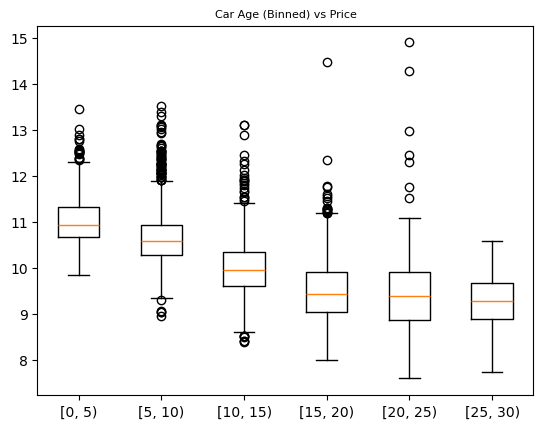

In [18]:
# Scatter plot of Mileage vs price:
# Boxplot of Car Age vs Price
df_new["age_bin"] = pd.cut(df_new["age"], bins=[0, 5, 10, 15, 20,25,30], right=False)

age_types = df_new["age_bin"].cat.categories
price_groups = [df_new[df_new["age_bin"] == b]["price"] for b in age_types]

plt.boxplot(price_groups, tick_labels=age_types)
plt.title('Car Age (Binned) vs Price', fontsize=8)